In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import 

In [4]:
df=pd.read_csv("Mall_Customers.csv")
df.head()


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
#for unpervised learning we dont have output cloumn


In [10]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_scaled=scaler.fit_transform(X)

ELbow method

C:\Users\Sreelekha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Sreelekha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Sreelekha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Sreelekha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

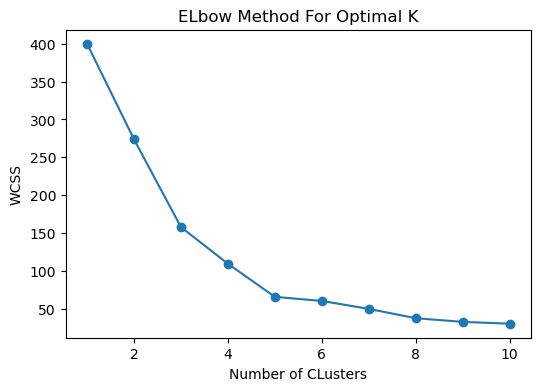

In [19]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    
0plt.figure(figsize=(6,4))
plt.plot(range(1,11),wcss,marker='o')
plt.title("ELbow Method For Optimal K")
plt.xlabel("Number of CLusters")
plt.ylabel("WCSS")
plt.show()

In [22]:
kmeans = KMeans(n_clusters=5,random_state=42)
df["KMeans_cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Sreelekha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [24]:
df["KMeans_cluster"] =df["KMeans_cluster"] + 1

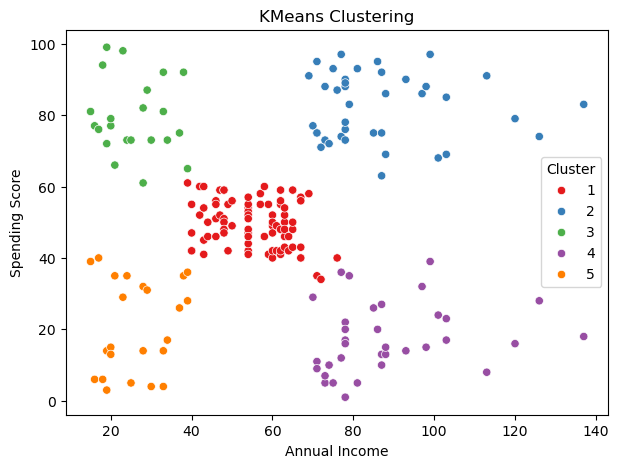

In [26]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["KMeans_cluster"],
    palette="Set1"
)

plt.title("KMeans Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.legend(title="Cluster")
plt.show()
    
        
    